# L1.5 — Tune Boss

Hands-on notebook for the lesson [`1-5-tune-boss.mdx`](../../llm-quest-theory/level-1/1-5-tune-boss.mdx).

> **Learning objectives**
> - Diagnose a "stuck" training run by reading its loss curve.
> - Systematically grid-search over learning rate and batch size.
> - Defeat the boss: push the final MSE below **0.5** in under **200 steps**.

## Connection to the theory
Combines lessons 1-1 (loss), 1-2 (gradient descent), 1-3 (learning rate). The boss asks you to play the role of a practitioner debugging a training run.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. The stuck scenario
8 data points generated from `y = 2x + 1 + small noise`. The starter trainer uses a very small learning rate and terrible initialization — we will show its diagnostics first, then fix it.

In [2]:
N = 8
x = np.linspace(-2, 2, N)
y = 2.0 * x + 1.0 + np.random.normal(0, 0.2, size=N)

def loss(a, b):
    return float(np.mean((a * x + b - y) ** 2))

def grads(a, b):
    err = a * x + b - y
    return 2 * float(np.mean(err * x)), 2 * float(np.mean(err))

def train(a0, b0, lr, n_steps=200, batch_size=None, rng=None):
    a, b = float(a0), float(b0)
    rng = rng or np.random.default_rng(SEED)
    history = [loss(a, b)]
    for _ in range(n_steps):
        if batch_size is None or batch_size >= N:
            da, db = grads(a, b)
        else:
            idx = rng.choice(N, size=batch_size, replace=False)
            err = a * x[idx] + b - y[idx]
            da = 2 * float(np.mean(err * x[idx]))
            db = 2 * float(np.mean(err))
        a -= lr * da
        b -= lr * db
        history.append(loss(a, b))
    return (a, b), np.array(history)

In [3]:
# Starter config: way too small lr, slightly off initialization
(a0, b0), hist_stuck = train(a0=-5.0, b0=5.0, lr=0.002, n_steps=200, batch_size=None)
print(f"Starter config final: a={a0:.3f}, b={b0:.3f}, loss={hist_stuck[-1]:.4f}")
print("Boss gate: loss < 0.5  ->", "PASS" if hist_stuck[-1] < 0.5 else "FAIL")

Starter config final: a=0.251, b=2.855, loss=8.4592
Boss gate: loss < 0.5  -> FAIL


## 2. Diagnose by looking at the loss curve
Slow, monotonic decrease with no oscillation = learning rate is too small. Let's sweep a handful of learning rates at the same initialization.

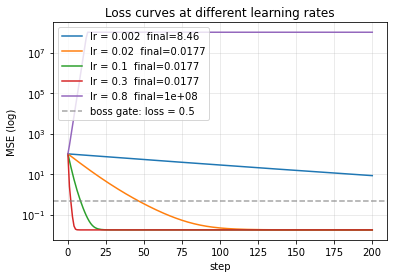

In [4]:
lrs = [0.002, 0.02, 0.1, 0.3, 0.8]
fig, ax = plt.subplots()
for lr in lrs:
    _, h = train(a0=-5.0, b0=5.0, lr=lr, n_steps=200)
    clipped = np.clip(h, 1e-6, 1e8)
    ax.plot(clipped, label=f"lr = {lr}  final={clipped[-1]:.3g}")
ax.axhline(0.5, linestyle="--", color="gray", alpha=0.7, label="boss gate: loss = 0.5")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("MSE (log)")
ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Loss curves at different learning rates")
plt.show()

## 3. Grid search: learning rate x batch size
Run every combination, record the best loss inside the 200-step budget and the step at which it was reached.

In [5]:
lr_grid   = [0.005, 0.02, 0.05, 0.1, 0.2, 0.4]
bs_grid   = [1, 2, 4, 8]  # 8 == full batch since N=8

results = np.full((len(lr_grid), len(bs_grid)), np.nan)
for i, lr in enumerate(lr_grid):
    for j, bs in enumerate(bs_grid):
        (_, _), h = train(a0=-5.0, b0=5.0, lr=lr, n_steps=200, batch_size=bs,
                          rng=np.random.default_rng(SEED))
        results[i, j] = h[-1]

print("        bs=1     bs=2     bs=4     bs=8")
for i, lr in enumerate(lr_grid):
    row = "  ".join(f"{results[i, j]:>7.3f}" for j in range(len(bs_grid)))
    print(f"lr={lr:<5} {row}")

        bs=1     bs=2     bs=4     bs=8
lr=0.005   0.510    0.441    0.506    0.373
lr=0.02    0.018    0.018    0.018    0.018
lr=0.05    0.018    0.018    0.018    0.018
lr=0.1     0.018    0.018    0.018    0.018
lr=0.2     0.025    0.026    0.018    0.018
lr=0.4    25.038    0.111    0.019    0.018


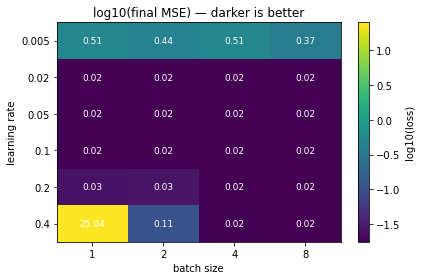

In [6]:
fig, ax = plt.subplots()
im = ax.imshow(np.log10(np.clip(results, 1e-6, 1e6)), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(bs_grid))); ax.set_xticklabels(bs_grid)
ax.set_yticks(range(len(lr_grid))); ax.set_yticklabels(lr_grid)
ax.set_xlabel("batch size"); ax.set_ylabel("learning rate")
ax.set_title("log10(final MSE) — darker is better")
for i in range(len(lr_grid)):
    for j in range(len(bs_grid)):
        val = results[i, j]
        txt = f"{val:.2f}" if np.isfinite(val) else "inf"
        ax.text(j, i, txt, ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax, label="log10(loss)")
plt.tight_layout(); plt.show()

## 4. Pick the winning config and rerun
Find the entry with the lowest final loss and verify it clears the boss gate.

In [7]:
best_i, best_j = np.unravel_index(np.nanargmin(results), results.shape)
best_lr = lr_grid[best_i]
best_bs = bs_grid[best_j]
print(f"Best config: lr = {best_lr}, batch_size = {best_bs}, loss = {results[best_i, best_j]:.4f}")

(a_star, b_star), hist_best = train(a0=-5.0, b0=5.0, lr=best_lr, n_steps=200,
                                    batch_size=best_bs, rng=np.random.default_rng(SEED))
print(f"Learned: a = {a_star:.3f}, b = {b_star:.3f}  (ground truth: a=2.0, b=1.0)")
print("Boss gate (loss < 0.5):", "PASS" if hist_best[-1] < 0.5 else "FAIL")

Best config: lr = 0.1, batch_size = 8, loss = 0.0177
Learned: a = 2.025, b = 1.110  (ground truth: a=2.0, b=1.0)
Boss gate (loss < 0.5): PASS


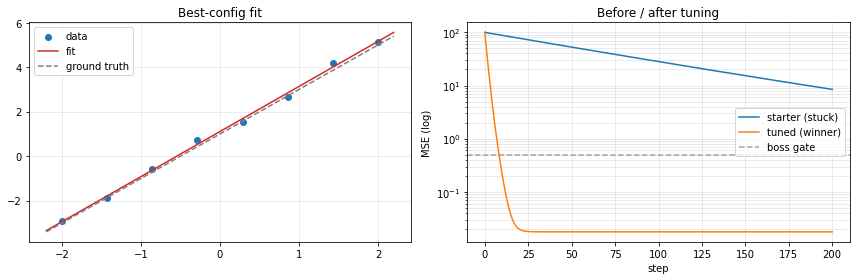

In [8]:
xs_plot = np.linspace(-2.2, 2.2, 50)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x, y, label="data", color="tab:blue")
axes[0].plot(xs_plot, a_star * xs_plot + b_star, color="tab:red", label="fit")
axes[0].plot(xs_plot, 2 * xs_plot + 1, color="gray", linestyle="--", label="ground truth")
axes[0].grid(alpha=0.3); axes[0].legend(); axes[0].set_title("Best-config fit")

axes[1].plot(hist_stuck, label="starter (stuck)")
axes[1].plot(hist_best,  label="tuned (winner)")
axes[1].axhline(0.5, linestyle="--", color="gray", alpha=0.7, label="boss gate")
axes[1].set_yscale("log"); axes[1].set_xlabel("step"); axes[1].set_ylabel("MSE (log)")
axes[1].grid(alpha=0.3, which="both"); axes[1].legend(); axes[1].set_title("Before / after tuning")
plt.tight_layout(); plt.show()

## 5. Boss gates (quick checks)

In [9]:
assert hist_stuck[-1] > 1.0, "the stuck scenario must fail the gate (by design)"
assert hist_best[-1] < 0.5,  "the tuned config must clear the boss gate"
assert abs(a_star - 2.0) < 0.2 and abs(b_star - 1.0) < 0.3
assert np.nanmin(results) < 0.5, "the grid must contain at least one passing config"
print("All boss gates passed.")

All boss gates passed.


## 6. Self-assessment quiz

1. Why does a learning rate that is too large cause the loss to oscillate? (Hint: relate this to the second derivative of the loss.)
2. With 8 data points we can use full-batch GD every step. If the dataset had **1 million** points, would you pick batch, mini-batch, or pure SGD? Why?
3. If we swap the loss from MSE to MAE, how does the shape of the gradient change — and what does that mean for gradient descent near the minimum?
4. Add a feature `x^2` to the model: `y_hat = a x + c x^2 + b`. Does the *minimum achievable loss* go down, up, or stay the same? Why?
5. If we normalize `x` to `(x - mean(x)) / std(x)` before training, how should the best learning rate change?

<details>
<summary>Hints for the answers</summary>

1. Each GD step overshoots the local quadratic approximation when `eta > 2 / L`, where `L` is the Lipschitz constant of the gradient (basically a bound on the second derivative).
2. Mini-batch: cheaper than full-batch per step but much more stable than pure SGD. Pure SGD is almost never used at scale.
3. MAE's gradient is a constant sign (`±1`) — it doesn't shrink near the minimum, so plain GD tends to oscillate without further tricks like step-size decay.
4. The minimum can only go down or stay the same: adding a feature enlarges the model's hypothesis space, so the best achievable loss cannot increase. If the true generator is linear, it stays the same.
5. After normalization the loss surface is more isotropic, so a larger `lr` becomes safe. Good default: ~10x larger than without normalization.
</details>

## 7. Stretch exercises

- Replace plain GD with the Adam implementation from lesson 1-3 and rerun the grid — does the winning cell change?
- Add a cosine-annealing schedule with `lr_max = best_lr` and see how many steps are needed to hit `loss < 0.1`.
- Change the dataset to include one big outlier and observe which combinations of `(lr, batch_size)` still pass.

## References
- Source theory: [`1-5-tune-boss.mdx`](../../llm-quest-theory/level-1/1-5-tune-boss.mdx)
- Moving on: [Level 2](../level-2/README.md) — proper regression, classification, bias / variance.